Unindo dados

In [1]:
import pandas as pd

In [2]:
path = r'C:\Users\logistica.wms\OneDrive - SANTA FÉ\Documents\Cursos\Alura\Alura\Pandas - selecionando e agrupando dados\dados\POP2022_Municipios(Municípios).csv'

dados_populacao = pd.read_csv(path,
                              sep=';',
                              encoding='ISO-8859-1',
                              header=1,
                              skipfooter=34,
                              engine='python')

In [3]:
dados_populacao.head(5)

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO
0,RO,11,15,Alta Floresta D'Oeste,21.558
1,RO,11,23,Ariquemes,100.896
2,RO,11,31,Cabixi,5.107
3,RO,11,49,Cacoal,92.202
4,RO,11,56,Cerejeiras,15.237


In [4]:
df = pd.DataFrame(dados_populacao)

In [5]:
df[df[' POPULAÇÃO '].str.contains('\\(')]

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO
16,RO,11,205,Porto Velho,461.748(1)
74,AM,13,29,Alvarães,15.916(2)
81,AM,13,409,Barcelos,18.399(3)
83,AM,13,607,Benjamin Constant,37.436(4)
87,AM,13,805,Borba,33.209(5)
88,AM,13,839,Caapiranga,13.851(6)
97,AM,13,1605,Fonte Boa,27.692(7)
98,AM,13,1654,Guajará,13.809(8)
99,AM,13,1704,Humaitá,59.504(9)
103,AM,13,1951,Itamarati,10.783(10)


In [6]:
dados_populacao.groupby('UF').sum(numeric_only=True).sort_index(ascending=False)

,COD. UF,COD. MUNIC
UF,,
TO,2363,1605293
SP,22575,18510133
SE,2100,294557
SC,12390,2894993
RS,21371,5903048
RR,210,4693
RO,572,35443
RN,4008,1276977
RJ,3036,287819


In [7]:
dados_populacao[dados_populacao[' POPULAÇÃO '].str.contains('\\(')]

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO
16,RO,11,205,Porto Velho,461.748(1)
74,AM,13,29,Alvarães,15.916(2)
81,AM,13,409,Barcelos,18.399(3)
83,AM,13,607,Benjamin Constant,37.436(4)
87,AM,13,805,Borba,33.209(5)
88,AM,13,839,Caapiranga,13.851(6)
97,AM,13,1605,Fonte Boa,27.692(7)
98,AM,13,1654,Guajará,13.809(8)
99,AM,13,1704,Humaitá,59.504(9)
103,AM,13,1951,Itamarati,10.783(10)


In [8]:
dados_populacao = dados_populacao.assign(populacao_sem_parenteses = dados_populacao[' POPULAÇÃO '].replace('\\(\\d{1,2}\\)', '', regex= True),
                                         populacao = lambda x : x.loc[:, 'populacao_sem_parenteses'].replace('\\.', '', regex= True))

In [9]:
dados_populacao = dados_populacao.astype({'populacao' : 'int'})

In [10]:
dados_populacao = dados_populacao.groupby('UF')[['populacao']].sum(numeric_only=True).reset_index()
dados_populacao

,UF,populacao
0,AC,829780
1,AL,3125254
2,AM,3952262
3,AP,774268
4,BA,14659023
5,CE,8936431
6,DF,2923369
7,ES,3975100
8,GO,6950976
9,MA,6800605


In [11]:
path = r'C:\Users\logistica.wms\OneDrive - SANTA FÉ\Documents\Cursos\Alura\Alura\Pandas - selecionando e agrupando dados\dados\1-SEEG10_GERAL-BR_UF_2022.10.27-FINAL-SITE.xlsx'
dados_emissao = pd.read_excel(path, sheet_name='GEE Estados')

c:\Users\logistica.wms\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [12]:
colunas_info = list(dados_emissao.loc[:, 'Nível 1 - Setor':'Produto'].columns)
colunas_valores = list(dados_emissao.loc[:, 1970:2021].columns)

dados_emissao = dados_emissao.melt( id_vars=        colunas_info, 
                                    value_vars=     colunas_valores, 
                                    var_name=       'Ano', 
                                    value_name=     'Emissão'   )

In [13]:
dados_emissao.head()

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,Produto,Ano,Emissão
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,Emissão,COVNM (t),SP,OUTRA_IND,NaN,1970,0.0
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,N2O (t),SP,OUTRA_IND,NaN,1970,6210.0
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO (t),SP,OUTRA_IND,NaN,1970,368.0
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,NOx (t),SP,OUTRA_IND,NaN,1970,115.0
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,1970,1925100.0


In [14]:
emissoes_totais = dados_emissao.groupby('Estado')[['Emissão']].sum().reset_index()

In [15]:
dados_agrupados = pd.merge(emissoes_totais, dados_populacao, left_on="Estado", right_on="UF")

In [16]:
dados_agrupados

,Estado,Emissão,UF,populacao
0,AC,4.613750e+09,AC,829780
1,AL,2.257329e+09,AL,3125254
2,AM,-1.311181e+10,AM,3952262
3,AP,-2.208872e+09,AP,774268
4,BA,1.986715e+10,BA,14659023
5,CE,5.541074e+09,CE,8936431
6,DF,1.478120e+09,DF,2923369
7,ES,7.294725e+09,ES,3975100
8,GO,1.980117e+10,GO,6950976
9,MA,2.083963e+10,MA,6800605


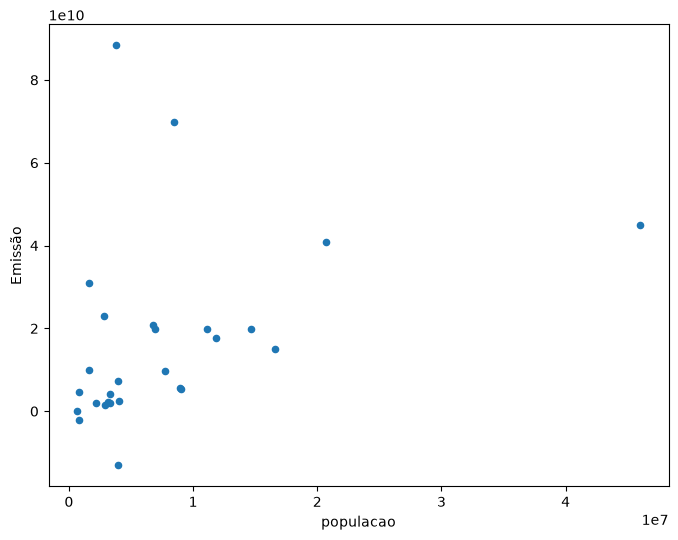

In [17]:
dados_agrupados.plot(x='populacao', y='Emissão', kind='scatter', figsize=(8,6));

In [18]:
import plotly.express as px

In [19]:
px.scatter(data_frame= dados_agrupados, 
            x='populacao',
            y='Emissão',
            text='Estado',
            opacity=0)